Note: you may need to restart the kernel to use updated packages.
Using dataset: final_features_1.csv
Base features: ['season', 'platt_apag_mom_pct', 'platt_crude_mom_pct', 'temp_avg', 'precip_avg', 'threshold_temp_days', 'threshold_rainy_days', 'possible_working_days', 'avg_weight']
Train: 264 rows (2001-01-31 00:00:00 ~ 2022-12-31 00:00:00)
Valid: 32 rows (2023-01-31 00:00:00 ~ 2025-08-31 00:00:00)

Total features: 11
All feature list: ['season', 'platt_apag_mom_pct', 'platt_crude_mom_pct', 'temp_avg', 'precip_avg', 'threshold_temp_days', 'threshold_rainy_days', 'possible_working_days', 'avg_weight', 'year', 'month']

Training samples: 264
Validation samples: 32

Starting LightGBM hyperparameter tuning...
This may take several minutes...

Fitting 3 folds for each of 50 candidates, totalling 150 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total B

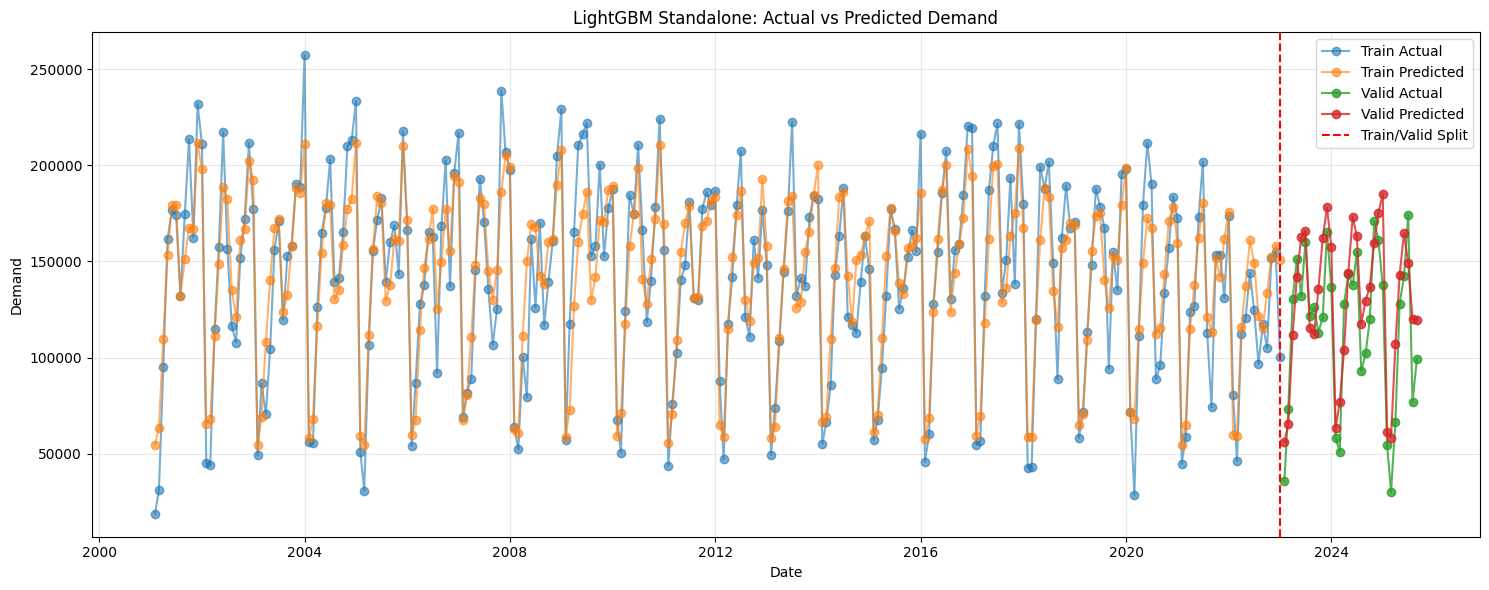


Top 10 Most Important Features:
                  feature  importance
3                temp_avg         483
9                    year         476
8              avg_weight         444
1      platt_apag_mom_pct         310
4              precip_avg         265
7   possible_working_days         237
2     platt_crude_mom_pct         225
10                  month          86
0                  season          74
5     threshold_temp_days          45


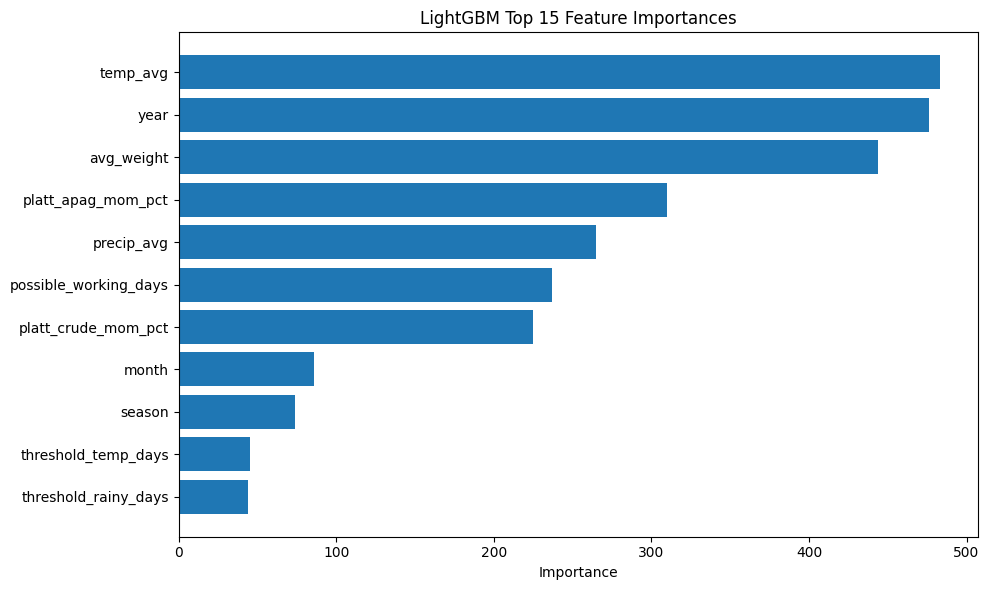

Model saved to ../models/lightgbm_standalone.txt


In [3]:
%pip install lightgbm

# LightGBM Standalone Model
# Using final_features_1 or 2 with engineered features

### 1. Load and Prepare Data
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt

# ========== CONFIGURATION: CHANGE THESE VALUES ==========
# Choose which dataset to use: 1 or 2
DATASET_VERSION = 1  # 1: final_features_1.csv, 2: final_features_2.csv

FEATURE_CONFIGS = {
    1: {
        'file': '../data/final_features_1.csv',
        'features': [
            "season",
            "platt_apag_mom_pct",
            "platt_crude_mom_pct",
            "temp_avg",
            "precip_avg",
            "threshold_temp_days",
            "threshold_rainy_days",
            "possible_working_days",
            "avg_weight"
        ],
        'name': 'final_features_1.csv'
    },
    2: {
        'file': '../data/final_features_2.csv',
        'features': [
            "quarter",
            "season_sin",
            "season_cos",
            "temp_avg",
            "precip_avg",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight"
        ],
        'name': 'final_features_2.csv'
    },
    3: {
        'file': '../data/final_features_4.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_4.csv'
    },
    4: {
        'file': '../data/final_features_5.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_5.csv'
    },
    5: {
        'file': '../data/final_features_6.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_6.csv'
    },
}
# ========================================================

config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config['file'])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)
dataset_name = config['name']
feature_cols = config['features']

# Ensure numeric types
for col in feature_cols:
    df[col] = df[col].astype(float)

# Target
df["demand"] = df["demand"].astype(float)

# Train/validation split (last 32 months as validation)
cutoff = df["ds"].max() - pd.DateOffset(months=32)
df_train = df[df["ds"] <= cutoff].copy()
df_valid = df[df["ds"] > cutoff].copy()

print(f"Using dataset: {dataset_name}")
print(f"Base features: {feature_cols}")
print(f"Train: {len(df_train)} rows ({df_train['ds'].min()} ~ {df_train['ds'].max()})")
print(f"Valid: {len(df_valid)} rows ({df_valid['ds'].min()} ~ {df_valid['ds'].max()})")

### 2. Add Simple Time Features (year, month)
df_train["year"] = df_train["ds"].dt.year
df_train["month"] = df_train["ds"].dt.month

df_valid["year"] = df_valid["ds"].dt.year
df_valid["month"] = df_valid["ds"].dt.month

time_features = ["year", "month"]
all_features = feature_cols + time_features

print(f"\nTotal features: {len(all_features)}")
print(f"All feature list: {all_features}")

### 3. Prepare Data for LightGBM
X_train = df_train[all_features]
y_train = df_train["demand"]
X_valid = df_valid[all_features]
y_valid = df_valid["demand"]

print(f"\nTraining samples: {len(X_train)}")
print(f"Validation samples: {len(X_valid)}")

### 4. Hyperparameter Tuning (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "n_estimators": [300, 500, 700, 1000],
    "min_child_samples": [5, 10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 1.5, 2.0]
}

base_model = lgb.LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=-1
)

print("\nStarting LightGBM hyperparameter tuning...")
print("This may take several minutes...\n")

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,  # number of combinations
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\n" + "="*60)
print("Best LightGBM Parameters:")
print("="*60)
best_params = random_search.best_params_
for k, v in best_params.items():
    print(f"  {k}: {v}")

best_rmse = np.sqrt(-random_search.best_score_)
print(f"\nBest CV RMSE: {best_rmse:,.2f}")

### 5. Train Final LightGBM Model with Early Stopping
model = lgb.LGBMRegressor(
    **best_params,
    objective="regression",
    random_state=42,
    n_jobs=-1
)

print("\nTraining final LightGBM model with best parameters...")

# Use callbacks for early stopping (compatible with LightGBM v4.0+)
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=callbacks
)

print("Training complete.")
try:
    print(f"Best iteration: {model.best_iteration_}")
except AttributeError:
    print("Best iteration not available in this LightGBM version.")

### 6. Evaluate Model
def calculate_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100

    print(f"\n{label} Metrics:")
    print(f"  RMSE:  {rmse:,.1f}")
    print(f"  MAE:   {mae:,.1f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  RMSPE: {rmspe:.2f}%")

    return {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "rmspe": rmspe
    }

train_pred = model.predict(X_train)
valid_pred = model.predict(X_valid)

train_metrics = calculate_metrics(y_train, train_pred, "Training")
valid_metrics = calculate_metrics(y_valid, valid_pred, "Validation")

### 7. Save Results to JSON
import json
from datetime import datetime
import glob
import re
import os

os.makedirs("../results", exist_ok=True)

current_params = best_params
existing_files = glob.glob(f"../results/lightgbm_feature{DATASET_VERSION}_results_*.json")

params_exist = False
existing_run = None

for file in existing_files:
    try:
        with open(file, "r") as f:
            existing_data = json.load(f)
            if existing_data.get("best_parameters") == current_params:
                params_exist = True
                existing_run = file
                break
    except:
        continue

if params_exist:
    print("\n" + "="*60)
    print("⚠️  RESULTS NOT SAVED (same hyperparameters already exist)")
    print(f"File: {existing_run}")
    print("="*60)
else:
    run_numbers = []
    for file in existing_files:
        m = re.search(rf"lightgbm_feature{DATASET_VERSION}_results_(\d+)\.json", file)
        if m:
            run_numbers.append(int(m.group(1)))
    next_run = max(run_numbers) + 1 if run_numbers else 1

    results = {
        "model_name": f"LightGBM Standalone - {dataset_name}",
        "run_number": next_run,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_name,
        "features": all_features,
        "num_features": len(all_features),
        "train_samples": int(len(X_train)),
        "valid_samples": int(len(X_valid)),
        "best_parameters": current_params,
        "metrics": {
            "training": {
                "rmse": float(train_metrics["rmse"]),
                "mae": float(train_metrics["mae"]),
                "mape": float(train_metrics["mape"]),
                "rmspe": float(train_metrics["rmspe"])
            },
            "validation": {
                "rmse": float(valid_metrics["rmse"]),
                "mae": float(valid_metrics["mae"]),
                "mape": float(valid_metrics["mape"]),
                "rmspe": float(valid_metrics["rmspe"])
            }
        }
    }

    result_path = f"../results/lightgbm_feature{DATASET_VERSION}_results_{next_run}.json"
    with open(result_path, "w") as f:
        json.dump(results, f, indent=2)

    print("\n" + "="*60)
    print(f"✅ Results saved to: {result_path}")
    print(f"Run number: {next_run}")
    print("="*60)

### 8. Visualization: Actual vs Predicted
import matplotlib.pyplot as plt

viz_train = df_train.copy()
viz_train["prediction"] = train_pred

viz_valid = df_valid.copy()
viz_valid["prediction"] = valid_pred

plt.figure(figsize=(15, 6))
plt.plot(viz_train["ds"], viz_train["demand"], "o-", label="Train Actual", alpha=0.6)
plt.plot(viz_train["ds"], viz_train["prediction"], "o-", label="Train Predicted", alpha=0.6)
plt.plot(viz_valid["ds"], viz_valid["demand"], "o-", label="Valid Actual", alpha=0.8)
plt.plot(viz_valid["ds"], viz_valid["prediction"], "o-", label="Valid Predicted", alpha=0.8)
plt.axvline(x=cutoff, linestyle="--", color="red", label="Train/Valid Split")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("LightGBM Standalone: Actual vs Predicted Demand")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Visualization: Feature Importance
feature_importance = pd.DataFrame({
    "feature": all_features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"].head(15),
         feature_importance["importance"].head(15))
plt.xlabel("Importance")
plt.title("LightGBM Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 10. Save Model (Optional)
os.makedirs("../models", exist_ok=True)
model_path = "../models/lightgbm_standalone.txt"
model.booster_.save_model(model_path)
print(f"Model saved to {model_path}")